In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("data.csv")


In [3]:
df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,6021
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,5914
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,4645
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,5831
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,6199


In [4]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(df))

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

Training set size: 400
Testing set size: 100


<Figure size 1000x800 with 0 Axes>

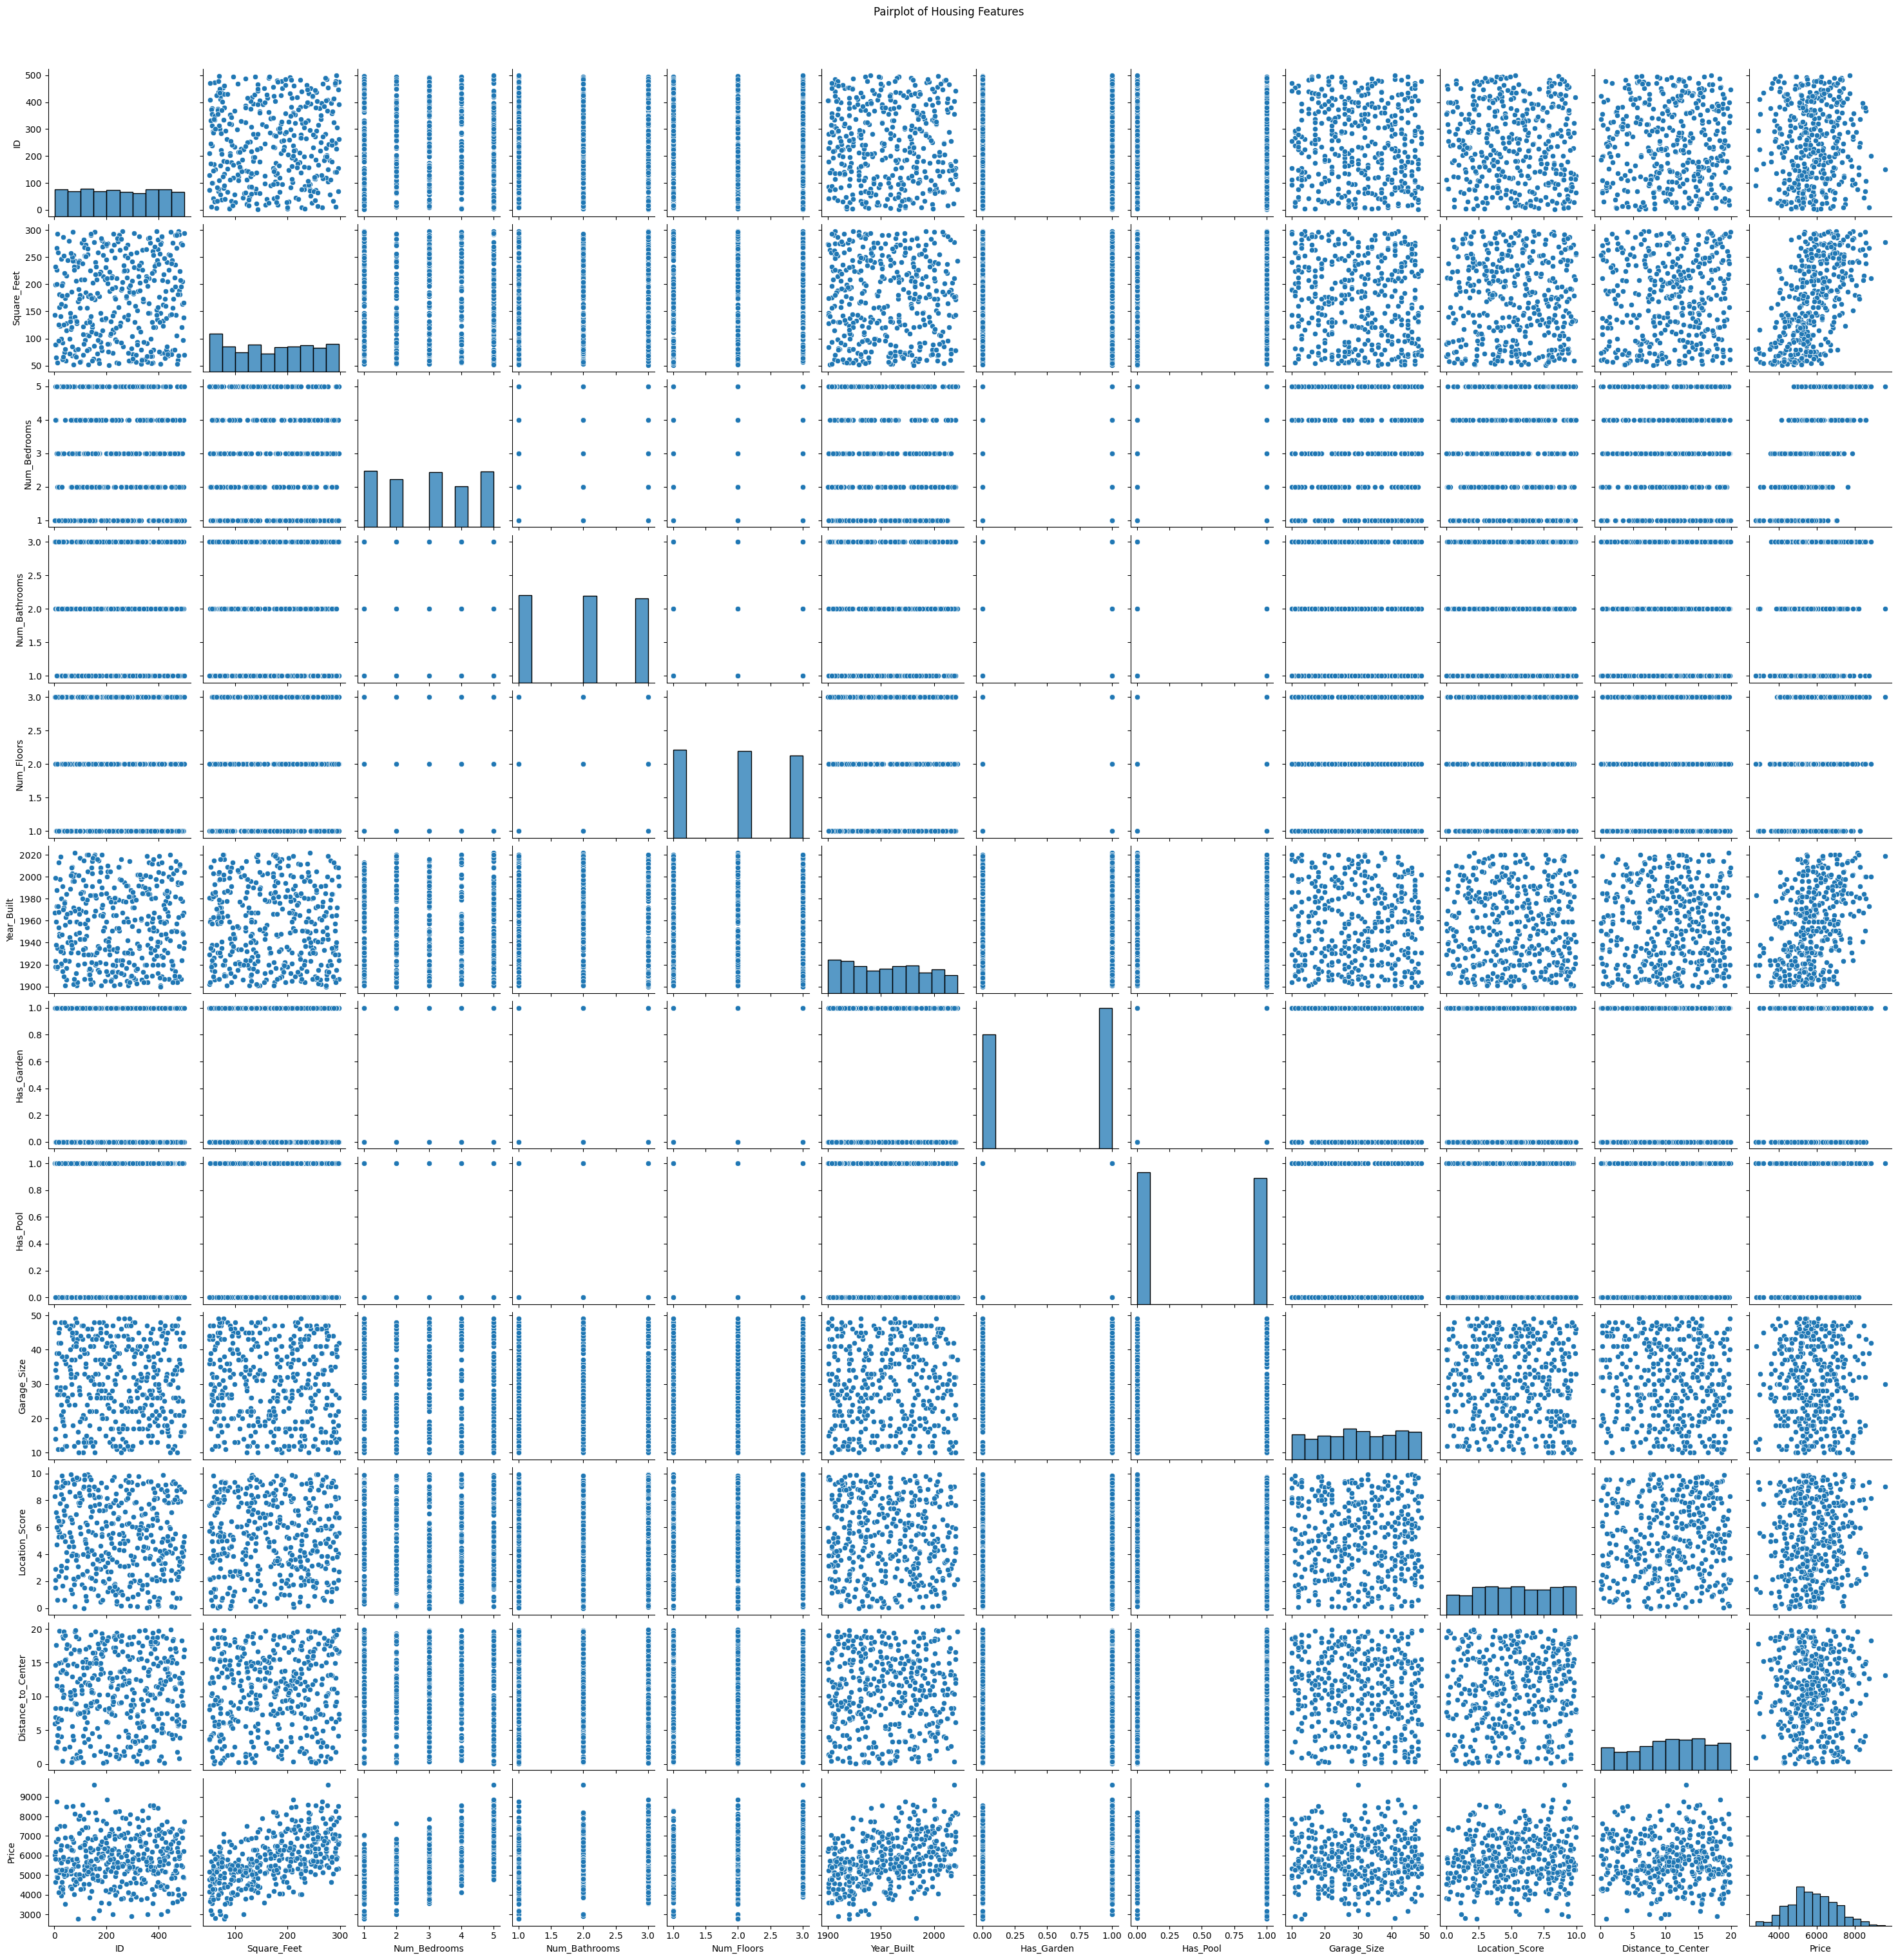

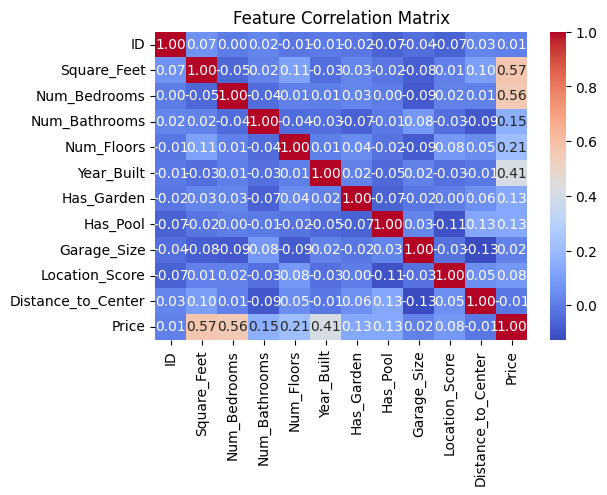

In [5]:
#Pairplot to visualize relationships between all variables
plt.figure(figsize=(10, 8))
sns.pairplot(train_df)
plt.suptitle('Pairplot of Housing Features', y=1.02)
plt.show()

#Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
#see how many missing values were ruining the math
print("Missing values before cleaning:")
print(train_df[['Square_Feet', 'Num_Bedrooms', 'Price']].isna().sum())

#Drop any rows that have missing data in our specific columns
train_clean = train_df.dropna(subset=['Square_Feet', 'Num_Bedrooms', 'Price'])
test_clean = test_df.dropna(subset=['Square_Feet', 'Num_Bedrooms', 'Price'])

#Separate features (X) and target (y) using the CLEAN data
X_train = train_clean[['Square_Feet', 'Num_Bedrooms']].values
y_train = train_clean['Price'].values

X_test = test_clean[['Square_Feet', 'Num_Bedrooms']].values
y_test = test_clean['Price'].values

# Add the bias term (a column of ones) to X for the intercept
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]


X_T = X_train_b.T
X_T_X = X_T.dot(X_train_b)
X_T_X_inv = np.linalg.inv(X_T_X)
theta_best = X_T_X_inv.dot(X_T).dot(y_train)

print("\n--- Calculated Weights (Theta) ---")
print(f"Intercept: {theta_best[0]:.2f}")
print(f"Coefficient for Square_Feet: {theta_best[1]:.2f}")
print(f"Coefficient for Bedrooms: {theta_best[2]:.2f}")

Missing values before cleaning:
Square_Feet     4
Num_Bedrooms    5
Price           0
dtype: int64

--- Calculated Weights (Theta) ---
Intercept: 2571.75
Coefficient for Square_Feet: 10.05
Coefficient for Bedrooms: 504.19


In [ ]:

X_train = train_df[['Square_Feet', 'Bedrooms']].values
y_train = train_df['Price'].values

X_test = test_df[['Square_Feet', 'Bedrooms']].values
y_test = test_df['Price'].values

# Add the bias term (a column of ones) to X for the intercept
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]

# The Matrix Math (Normal Equation)
# 1. Transpose of X
X_T = X_train_b.T

# 2. X_T dot X
X_T_X = X_T.dot(X_train_b)

# 3. Inverse of (X_T dot X)
X_T_X_inv = np.linalg.inv(X_T_X)

# 4. Multiply by X_T and then by y
theta_best = X_T_X_inv.dot(X_T).dot(y_train)

print("Calculated Weights (Theta):")
print(f"Intercept: {theta_best[0]:.2f}")
print(f"Coefficient for Sqft: {theta_best[1]:.2f}")
print(f"Coefficient for Bedrooms: {theta_best[2]:.2f}")

In [ ]:


#Transpose of X
X_T = X_train_b.T

#X_T dot X (The heart of the matrix math)
X_T_X = X_T.dot(X_train_b)

#Inverse of (X_T dot X)
X_T_X_inv = np.linalg.inv(X_T_X)

#Multiply by X_T and then by y to get our golden weights (Theta)
theta_best = X_T_X_inv.dot(X_T).dot(y_train)

print("--- Calculated Weights (Theta) ---")
print(f"Intercept: {theta_best[0]:.2f}")
print(f"Coefficient for Square_Feet: {theta_best[1]:.2f}")
print(f"Coefficient for Num_Bedrooms: {theta_best[2]:.2f}")

--- Calculated Weights (Theta) ---
Intercept: 2571.75
Coefficient for Square_Feet: 10.05
Coefficient for Num_Bedrooms: 504.19


Residual Sum of Squares (RSS): 53,207,982.23
Mean Squared Error (MSE): 542,938.59


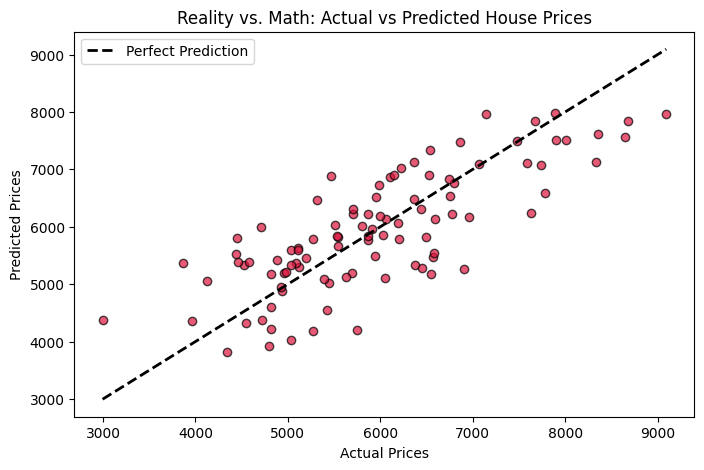

In [ ]:


y_predict = X_test_b.dot(theta_best)
# Calculate Residuals (Actual - Predicted)
residuals = y_test - y_predict

# Calculate Residual Sum of Squares (RSS)
rss = np.sum(residuals**2)

# Calculate Mean Squared Error (MSE)
mse = rss / len(y_test)

print(f"Residual Sum of Squares (RSS): {rss:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")

#Visualizing the True vs Predicted Prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_predict, alpha=0.7, color='crimson', edgecolor='k')

# The "Perfect Prediction" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Prediction")

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Reality vs. Math: Actual vs Predicted House Prices')
plt.legend()
plt.show()